# Исследование данных сервиса аренды самокатов

In [1]:
import pandas as pd
import numpy as np
from scipy import stats as st
import matplotlib.pyplot as plt

## Загрузка данных

### Считаем CSV-файлы с данными с помощью библиотеки pandas и сохраним их в датафреймы

In [2]:
try:
    users_go_data = pd.read_csv('/datasets/users_go.csv')
    rides_go_data = pd.read_csv('/datasets/rides_go.csv')
    subscriptions_go_data = pd.read_csv('/datasets/subscriptions_go.csv')
except:
    users_go_data = pd.read_csv('https://code.s3.yandex.net/datasets/users_go.csv')
    rides_go_data = pd.read_csv('https://code.s3.yandex.net/datasets/rides_go.csv')
    subscriptions_go_data = pd.read_csv('https://code.s3.yandex.net/datasets/subscriptions_go.csv')

### Выведим первые строки каждого набора данных. Изучим общую информацию о каждом датафрейме

In [3]:
users_go_data.head()

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


In [4]:
users_go_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB


Датасет users_go_data состоит из 1565 строк и 5 столбцов, которые содержат следующю информацию о Пользователях:  
* user_id	- уникальный идентификатор пользователя  
* name - имя пользователя  
* age - возраст  
* city - город  
* subscription_type - тип подписки (free, ultra)  

In [5]:
rides_go_data.head()

,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


In [6]:
rides_go_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB


Датасет rides_go_data состоит из 18068 строк и 4 столбцов, которые содержат следующю информацию о Поездках:  
* user_id - уникальный идентификатор пользователя  
* distance - расстояние, которое пользователь проехал в текущей сессии (в метрах)  
* duration - продолжительность сессии (в минутах) — время с того момента, как пользователь нажал кнопку «Начать поездку» до момента, как он нажал кнопку «Завершить поездку»  
* date - дата совершения поездки  

In [7]:
subscriptions_go_data.head()

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


In [8]:
subscriptions_go_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 192.0+ bytes


Датасет subscriptions_go_data состоит из 2 строк и 4 столбцов, которые содержат следующю информацию о Подписках:
* subscription_type - тип подписки
* minute_price - стоимость одной минуты поездки по данной подписке
* start_ride_price - стоимость начала поездки
* subscription_fee - стоимость ежемесячного платежа

## Предобработка данных

### Приведем столбец date к типу даты pandas

In [9]:
rides_go_data['date'] = pd.to_datetime(rides_go_data['date'], format='%Y-%m-%d')

In [10]:
# Проверим внесенные изменения. Столбец date изменил тип данных на datetime64
rides_go_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   18068 non-null  int64         
 1   distance  18068 non-null  float64       
 2   duration  18068 non-null  float64       
 3   date      18068 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 564.8 KB


### Создадим новый столбец с номером месяца на основе столбца date

In [11]:
rides_go_data['month'] = rides_go_data['date'].dt.month

In [12]:
# Добавили новый столбец с номерами месяцев. 
rides_go_data.head()

,user_id,distance,duration,date,month
0,1,4409.919140,25.599769,2021-01-01,1
1,1,2617.592153,15.816871,2021-01-18,1
2,1,754.159807,6.232113,2021-04-20,4
3,1,2694.783254,18.511000,2021-08-11,8
4,1,4028.687306,26.265803,2021-08-28,8


### Проверим наличие пропущенных значений и дубликатов в датафреймах. Обработаем их, если такие значения присутствуют

Проверим пропущенные значения во всех датасетах методом isna().

In [13]:
# В датасете users_go_data нет пропущенных значений
users_go_data.isna().sum()

user_id              0
name                 0
age                  0
city                 0
subscription_type    0
dtype: int64

In [14]:
# В датасете rides_go_data нет пропущенных значений
rides_go_data.isna().sum()

user_id     0
distance    0
duration    0
date        0
month       0
dtype: int64

In [15]:
# В датасете subscriptions_go_data нет пропущенных значений
subscriptions_go_data.isna().sum()

subscription_type    0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64

Проверим наличие явных дубликатов во всех датафреймах методом duplicated()

In [16]:
# В датасете users_go_data явных дубликатов - 31
users_go_data.duplicated().sum()

31

In [17]:
# Удалим явные дубликаты
users_go_data = users_go_data.drop_duplicates()

In [18]:
users_go_data.duplicated().sum()

0

In [19]:
# В датасете rides_go_data явных дубликатов нет
rides_go_data.duplicated().sum()

0

In [20]:
# В датасете subscriptions_go_data явных дубликатов нет
subscriptions_go_data.duplicated().sum()

0

### Вывод

На этапе предобработки данных были проверенны:  
  
- Типы данных во всех датасетах. Исправлен тип данных в столбце 'date' (rides_go_data) c object на datetime64  
- Пропущенные значения во всех датасетах. Пропуски не были обнаружены.  
- Явные дубликаты во всех датафреймах. В датасете users_go_data были найдены и удалены 31 явный дубликат  

Также в датафрейме rides_go_data был добавлен новый столбец с номерами месяцев 'month'  

## Исследовательский анализ данных

**Опишите и визуализируйте общую информацию о пользователях и поездках:**

### Частота встречаемости городов

In [21]:
# В датасете users_go_data встречается 8 уникальных городов
users_go_data['city'].unique()

array(['Тюмень', 'Омск', 'Москва', 'Ростов-на-Дону', 'Краснодар',
       'Пятигорск', 'Екатеринбург', 'Сочи'], dtype=object)

In [22]:
# Посмотрим частоту встречаемых городов методом value_counts()
users_go_data['city'].value_counts()

Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
Name: city, dtype: int64

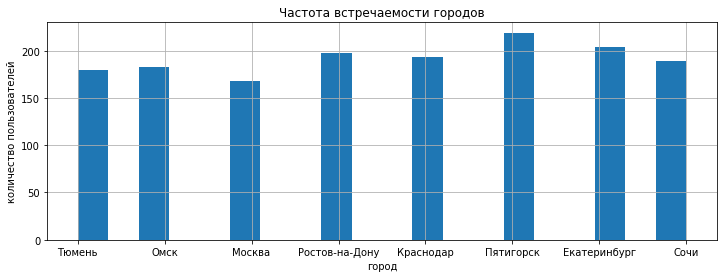

In [23]:
# Визуализируем частоту городов столбчатой диаграммой
users_go_data['city'].hist(bins = 20, grid = True, figsize = (12,4))
plt.title('Частота встречаемости городов')
plt.xlabel('город')
plt.ylabel('количество пользователей')
plt.show()

Наибольшее количество пользователей в городе Пятигорск (219), наименьшее в Москве (168)

### Соотношение пользователей с подпиской и без подписки

In [24]:
# Проверим общее количество пользователей с подпиской и без
users_go_data['subscription_type'].value_counts()

free     835
ultra    699
Name: subscription_type, dtype: int64

In [25]:
count_subscription_type = users_go_data['subscription_type'].value_counts()

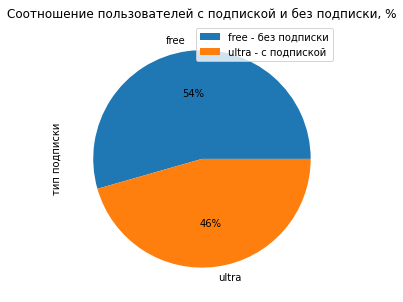

In [26]:
# Визуализируем соотношение пользователей с подпиской и без подписки в % круговой диаграммой
users_go_data['subscription_type'].value_counts().plot(
    kind = 'pie',  
    autopct = '%1.0f%%', 
    figsize=(5,5),
    title = 'Cоотношение пользователей с подпиской и без подписки, %',
    );
plt.ylabel('тип подписки')
plt.legend(['free - без подписки', 'ultra - с подпиской'])

Пользователей без подписки (free) 54%, с подпиской (ultra) немного меньше - 46%

### Возраст пользователей

In [27]:
# Самый младший пользователь - 12 лет, самый старший - 43 года
users_go_data['age'].value_counts()

25    145
24    132
26    131
23    129
27    119
22    119
28    112
21     93
20     71
30     68
29     68
31     48
19     47
18     46
32     41
33     39
17     26
34     19
16     19
35     15
15     13
14      9
13      8
36      6
12      4
38      3
37      2
39      1
43      1
Name: age, dtype: int64

In [28]:
users_go_data['age'].describe()

count    1534.000000
mean       24.903520
std         4.572367
min        12.000000
25%        22.000000
50%        25.000000
75%        28.000000
max        43.000000
Name: age, dtype: float64

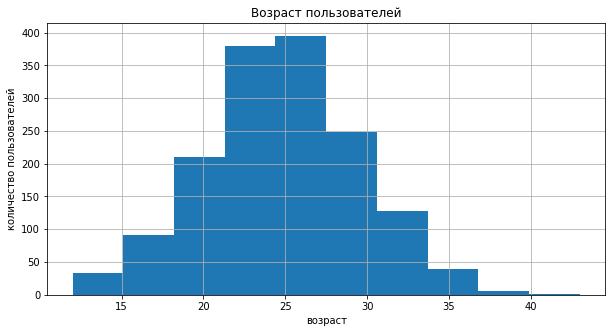

In [29]:
# Визуализируем возраст пользователей столбчатой диаграммой
users_go_data['age'].hist(bins = 10, grid = True, figsize = (10,5))
plt.title('Возраст пользователей')
plt.xlabel('возраст')
plt.ylabel('количество пользователей')
plt.show()

Возраст самых активных пользователей сервиса аренды самокатов GoFast от 22 до 28 лет. Средний возраст пользователей 25 лет.

### Расстояние, которое пользователь преодолел за одну поездку

In [30]:
rides_go_data['distance'].describe()

count    18068.000000
mean      3070.659976
std       1116.831209
min          0.855683
25%       2543.226360
50%       3133.609994
75%       3776.222735
max       7211.007745
Name: distance, dtype: float64

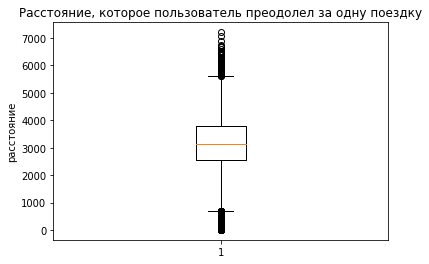

In [31]:
# Визуализируем расстояние, которое пользователи преодолели за одну поездку диаграммой размаха
plt.boxplot(rides_go_data['distance'])
plt.ylabel('расстояние')
plt.title('Расстояние, которое пользователь преодолел за одну поездку')
plt.show()

В среднем пользователь преодолевает за одну поездку 3070.65 м   
Максимальное расстояние, которое пользователи преодолевали за поезку, составляет 7211 м, минимальное - 0.85 м

### Продолжительность поездок

In [32]:
# Посмотрим общую информацию о продолжительности поездок
rides_go_data['duration'].describe()

count    18068.000000
mean        17.805011
std          6.091051
min          0.500000
25%         13.597563
50%         17.678395
75%         21.724800
max         40.823963
Name: duration, dtype: float64

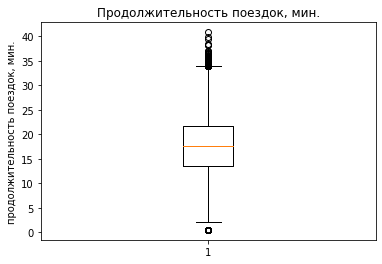

In [33]:
# Визуализируем продолжительность поездок диаграммой размаха
plt.boxplot(rides_go_data['duration'])
plt.ylabel('продолжительность поездок, мин.')
plt.title('Продолжительность поездок, мин.')
plt.show()

В среднем пользователь тратит на поездку 17.8 мин. Максимальная поездка заняла у пользователей 40.82 мин., минимальная всего лишь - 30 сек., что выглядит странно, скорее всего пользователь передумал пользоваться самокатом.

### Вывод

На этапе исследовательского анализа данных была описана и визуализированна общая информация о пользователях сервиса аренды самокатов GoFast и их поездках:  
* частота встречаемости городов;  
* соотношение пользователей с подпиской и без подписки;  
* возраст пользователей;  
* расстояние, которое пользователь преодолел за одну поездку;  
* продолжительность поездок.  

Количество пользователей по городам распределено примерно одинаково, нет выбивающихся значений. Наибольшее количество пользователей в городе Пятигорск (219), наименьшее в Москве (168).   

Пользователей, использующих бесплатную подписку (free) - 846, с подпиской (ultra) - 719.  
В % соотношении: free - 54%, ultra - 46%.  

Самым юным пользователям сервиса аренды самокатов GoFast 12 лет, самому старшему пользователю 43 года.  
Возраст большинства пользователей от 22 до 28 лет. Средний возраст - 25 лет.  

В среднем пользователь преодолевает за одну поездку 3070.65 м. Максимальное расстояние, которое пользователи преодолевали за поезку, составляет 7211 м, минимальное - 0.85 м.  

В основном длительность поездки состовляет 13 - 22 мин.В среднем пользователь тратит на поездку 17.8 мин. Максимальная поездка заняла у пользователей 40.82 мин., минимальная всего лишь - 30 сек., что выглядит странно, скорее всего пользователь передумал пользоваться самокатом или самокат был неисправен.  

## Объединение данных

### Объединим данные о пользователях, поездках и подписках в один датафрейм

Для этого воспользуемся методом merge()

In [34]:
# Объединим датасеты users_go_data и subscriptions_go по общему столбцу 'subscription_type' с помощью метода merge() 
# и сохраним в новом датасете new_data
new_data = users_go_data.merge(subscriptions_go_data, on='subscription_type', how='left')

In [35]:
# Теперь объединим новый датасет new_data с rides_go_data по общему столбцу 'user_id' с помощью метода merge() 
# и сохраним в новом датасете data
data = new_data.merge(rides_go_data, on='user_id', how='left')

In [36]:
data.head(10)

,user_id,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee,distance,duration,date,month
0,1,Кира,22,Тюмень,ultra,6,0,199,4409.919140,25.599769,2021-01-01,1
1,1,Кира,22,Тюмень,ultra,6,0,199,2617.592153,15.816871,2021-01-18,1
2,1,Кира,22,Тюмень,ultra,6,0,199,754.159807,6.232113,2021-04-20,4
3,1,Кира,22,Тюмень,ultra,6,0,199,2694.783254,18.511000,2021-08-11,8
4,1,Кира,22,Тюмень,ultra,6,0,199,4028.687306,26.265803,2021-08-28,8
5,1,Кира,22,Тюмень,ultra,6,0,199,2770.890808,16.650138,2021-10-09,10
6,1,Кира,22,Тюмень,ultra,6,0,199,3039.020292,14.927879,2021-10-19,10
7,1,Кира,22,Тюмень,ultra,6,0,199,2842.118050,23.117468,2021-11-06,11
8,1,Кира,22,Тюмень,ultra,6,0,199,3412.690668,15.238072,2021-11-14,11
9,1,Кира,22,Тюмень,ultra,6,0,199,748.690645,15.041884,2021-11-22,11


In [37]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 18068 entries, 0 to 18067
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            18068 non-null  int64         
 1   name               18068 non-null  object        
 2   age                18068 non-null  int64         
 3   city               18068 non-null  object        
 4   subscription_type  18068 non-null  object        
 5   minute_price       18068 non-null  int64         
 6   start_ride_price   18068 non-null  int64         
 7   subscription_fee   18068 non-null  int64         
 8   distance           18068 non-null  float64       
 9   duration           18068 non-null  float64       
 10  date               18068 non-null  datetime64[ns]
 11  month              18068 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(6), object(3)
memory usage: 1.8+ MB


Новый датасет data содержит 18068 строк и 12 столбцов

### Создадим ещё два датафрейма

* c данными о пользователях без подписки;
* с данными о пользователях с подпиской.

In [38]:
free_data = data.query("subscription_type == 'free'")
free_data.head()

,user_id,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee,distance,duration,date,month
6500,700,Айдар,22,Омск,free,8,50,0,2515.690719,14.944286,2021-01-02,1
6501,700,Айдар,22,Омск,free,8,50,0,846.932642,16.234663,2021-02-01,2
6502,700,Айдар,22,Омск,free,8,50,0,4004.434142,20.016628,2021-02-04,2
6503,700,Айдар,22,Омск,free,8,50,0,1205.911290,9.782872,2021-02-10,2
6504,700,Айдар,22,Омск,free,8,50,0,3047.379435,17.427673,2021-02-14,2


In [39]:
free_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11568 entries, 6500 to 18067
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            11568 non-null  int64         
 1   name               11568 non-null  object        
 2   age                11568 non-null  int64         
 3   city               11568 non-null  object        
 4   subscription_type  11568 non-null  object        
 5   minute_price       11568 non-null  int64         
 6   start_ride_price   11568 non-null  int64         
 7   subscription_fee   11568 non-null  int64         
 8   distance           11568 non-null  float64       
 9   duration           11568 non-null  float64       
 10  date               11568 non-null  datetime64[ns]
 11  month              11568 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(6), object(3)
memory usage: 1.1+ MB


In [40]:
ultra_data = data.query("subscription_type == 'ultra'")
ultra_data.head()

,user_id,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee,distance,duration,date,month
0,1,Кира,22,Тюмень,ultra,6,0,199,4409.919140,25.599769,2021-01-01,1
1,1,Кира,22,Тюмень,ultra,6,0,199,2617.592153,15.816871,2021-01-18,1
2,1,Кира,22,Тюмень,ultra,6,0,199,754.159807,6.232113,2021-04-20,4
3,1,Кира,22,Тюмень,ultra,6,0,199,2694.783254,18.511000,2021-08-11,8
4,1,Кира,22,Тюмень,ultra,6,0,199,4028.687306,26.265803,2021-08-28,8


In [41]:
ultra_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6500 entries, 0 to 6499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            6500 non-null   int64         
 1   name               6500 non-null   object        
 2   age                6500 non-null   int64         
 3   city               6500 non-null   object        
 4   subscription_type  6500 non-null   object        
 5   minute_price       6500 non-null   int64         
 6   start_ride_price   6500 non-null   int64         
 7   subscription_fee   6500 non-null   int64         
 8   distance           6500 non-null   float64       
 9   duration           6500 non-null   float64       
 10  date               6500 non-null   datetime64[ns]
 11  month              6500 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(6), object(3)
memory usage: 660.2+ KB


### Визуализируем информацию о расстоянии и времени поездок для пользователей обеих категорий

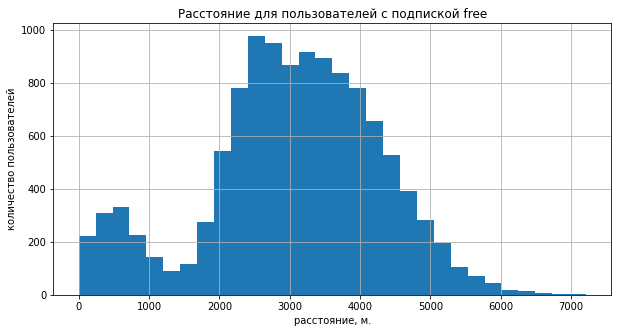

In [42]:
free_data['distance'].hist(bins = 30, grid = True, figsize = (10,5))
plt.title('Расстояние для пользователей с подпиской free')
plt.xlabel('расстояние, м.')
plt.ylabel('количество пользователей')
plt.show()

Пользователи тарифа free проезжают 2,2 - 4,2 км (в среднем 3 км). Есть пользователи, которые проехали больше 7 км. Также на графике мы видим пик до 1км. Возможно это пользователи, которые используют самокаты в дополнении к общественному транспорту: доехать до остановки автобуса/метро или от остановки автобуса/метро до дома или работы.

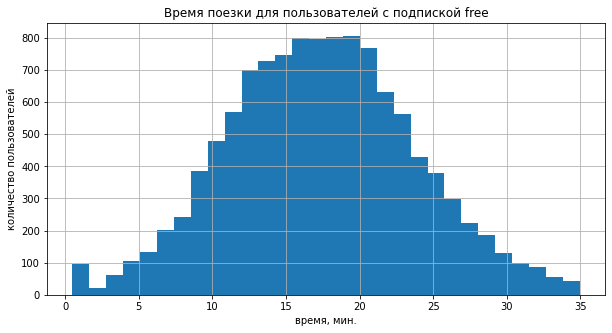

In [43]:
free_data['duration'].hist(bins = 30, grid = True, figsize = (10,5))
plt.title('Время поезки для пользователей с подпиской free')
plt.xlabel('время, мин.')
plt.ylabel('количество пользователей')
plt.show()

Для пользователей бесплатного тарифа (free) время поездки составляет 10-24 мин. (в среднем 17 мин.).


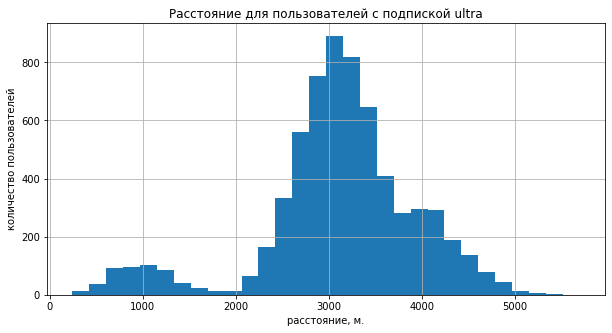

In [44]:
ultra_data['distance'].hist(bins = 30, grid = True, figsize = (10,5))
plt.title('Расстояние для пользователей с подпиской ultra')
plt.xlabel('расстояние, м.')
plt.ylabel('количество пользователей')
plt.show()

Пользователи с платной подпиской ultra проезжают 2,5-3,5 км (в среднем 3 км). Некоторые пользователи проезжают больше 5 км. Также на графике видим небольшой пик до 1 км. Как в случае с тарифом free, предполагаю, что это пользователи, которые используют самокаты в дополнении к общественному транспорту: доехать до остановки автобуса/метро или от остановки автобуса/метро до дома или работы

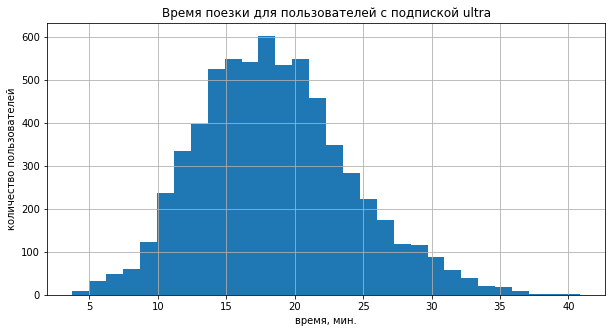

In [45]:
ultra_data['duration'].hist(bins = 30, grid = True, figsize = (10,5))
plt.title('Время поезки для пользователей с подпиской ultra')
plt.xlabel('время, мин.')
plt.ylabel('количество пользователей')
plt.show()

Для пользователей с платной подпиской ultra время поезки составляет 12-24 мин. (в среднем 18 мин.)

### Вывод

На данном этапе исследования объединили данные о пользователях, поездках и подписках в один датафрейм data.  

Создали ещё два дополнительных датафрейма из датафрейма data:   
* c данными о пользователях без подписки - free_data  
* с данными о пользователях с подпиской - ultra_data  

Визуализировали информацию о расстоянии и времени поездок для пользователей обеих категорий:

* Для пользователей бесплатного тарифа (free) время поездки составляет 10-24 мин. (в среднем 17 мин.). Большинство проезжает от 2,2 км до 4,2 км (в среднем 3 км), есть пользователи, которые проехали больше 7 км.

* Для пользователей с платной подпиской (ultra) время поезки составляет 12-24 мин. (в среднем 18 мин.). Большинство проезжает от 2,5 км до 3,5 км. (в среднм 3 км).

Таким образом, можно сделать вывод, что пользователи обеих категорий тратят примерно одинаковое время на поездки (17-18 мин.) и в среднем проезжают одинаковое расстояние (3 км.)

## Подсчёт выручки

### Создадим датафрейм с агрегированными данными о поездках на основе датафрейма с объединёнными данными

Найдем суммарное расстояние, количество поездок и суммарное время для каждого пользователя за каждый месяц.

In [49]:
data['duration'] = np.ceil(data['duration'])
data.head()

,user_id,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee,distance,duration,date,month
0,1,Кира,22,Тюмень,ultra,6,0,199,4409.919140,26.0,2021-01-01,1
1,1,Кира,22,Тюмень,ultra,6,0,199,2617.592153,16.0,2021-01-18,1
2,1,Кира,22,Тюмень,ultra,6,0,199,754.159807,7.0,2021-04-20,4
3,1,Кира,22,Тюмень,ultra,6,0,199,2694.783254,19.0,2021-08-11,8
4,1,Кира,22,Тюмень,ultra,6,0,199,4028.687306,27.0,2021-08-28,8


In [50]:
agg_data = data.groupby(['user_id', 'month']).agg({
    'distance': 'sum',
    'duration': 'sum',
    'name': 'count',
    'subscription_type': 'min',
    'start_ride_price': 'min',
    'minute_price': 'min',
    'subscription_fee': 'min'
}).reset_index()
agg_data

,user_id,month,distance,duration,name,subscription_type,start_ride_price,minute_price,subscription_fee
0,1,1,7027.511294,42.0,2,ultra,0,6,199
1,1,4,754.159807,7.0,1,ultra,0,6,199
2,1,8,6723.470560,46.0,2,ultra,0,6,199
3,1,10,5809.911100,32.0,2,ultra,0,6,199
4,1,11,7003.499363,56.0,3,ultra,0,6,199
...,...,...,...,...,...,...,...,...,...
11326,1534,6,3409.468534,26.0,2,free,50,8,0
11327,1534,8,7622.453034,48.0,2,free,50,8,0
11328,1534,9,4928.173852,23.0,1,free,50,8,0
11329,1534,11,13350.015305,78.0,4,free,50,8,0


### В этот же датафрейм добавим столбец с помесячной выручкой, которую принёс каждый пользователь.

Для этого обратимся к информации об условиях оплаты для подписчиков и тех, у кого нет подписки. Продолжительность каждой поездки в каждой строке исходного датафрейма для подсчёта стоимости округляется до следующего целого числа: например, значения 25.3, 25.5 и 26.0 должны быть преобразованы к 26.

In [53]:
def calculate_revenue(row):
    if row['subscription_type'] == 'ultra':
        return row['start_ride_price'] * row['name'] + row['minute_price'] * row['duration'] + row['subscription_fee']
    elif row['subscription_type'] == 'free':
        return row['start_ride_price'] * row['name'] + row['minute_price'] * row['duration']

agg_data['revenue_per_month'] = agg_data.apply(calculate_revenue, axis=1)
agg_data

,user_id,month,distance,duration,name,subscription_type,start_ride_price,minute_price,subscription_fee,revenue_per_month
0,1,1,7027.511294,42.0,2,ultra,0,6,199,451.0
1,1,4,754.159807,7.0,1,ultra,0,6,199,241.0
2,1,8,6723.470560,46.0,2,ultra,0,6,199,475.0
3,1,10,5809.911100,32.0,2,ultra,0,6,199,391.0
4,1,11,7003.499363,56.0,3,ultra,0,6,199,535.0
...,...,...,...,...,...,...,...,...,...,...
11326,1534,6,3409.468534,26.0,2,free,50,8,0,308.0
11327,1534,8,7622.453034,48.0,2,free,50,8,0,484.0
11328,1534,9,4928.173852,23.0,1,free,50,8,0,234.0
11329,1534,11,13350.015305,78.0,4,free,50,8,0,824.0


### Вывод

Создали новый датафрейм с агрегированными данными agg_data на основе датафрейма с объединенными данными data.

Нашли суммарное расстояние, количество поездок и суммарное время для каждого пользователя за каждый месяц. Также добавили столбец с помесячной выручкой revenue_per_month, которую принес каждый пользователь.

## Проверка гипотез

**Продакт-менеджеры сервиса хотят увеличить количество пользователей с подпиской. Для этого они будут проводить различные акции, но сначала нужно выяснить несколько важных моментов.**

### Важно понять, тратят ли пользователи с подпиской больше времени на поездки?

Если да, то пользователи с подпиской могут быть «выгоднее» для компании. Проверим гипотезу. Используем исходные данные о продолжительности каждой сессии — отдельно для подписчиков и тех, у кого нет подписки.

Проверим гипотезу: пользователи с подпиской тратят больше времени на поездки, чем пользователи на бесплатном тарифе.   

H_0: Время (duration) пользователей на подписке ultra = время (duration) пользователей на подписке free   
H_1: Время (duration) пользователей на подписке ultra > время (duration) пользователей на подписке free  
alpha = 0.05 (уровень статистической значимости)  

Для проверки гипотезы о равенстве среднего двух генеральных совокупностей по взятым из них выборкам применим метод st.ttest_ind   
Если p-value окажется меньше alpha, отвергнем гипотезу.

In [54]:
ultra_duration = ultra_data['duration'] 
free_duration = free_data['duration']

results = st.ttest_ind(ultra_duration, 
                       free_duration,
                       alternative = 'greater')

alpha = 0.05

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не удалось отвергнуть нулевую гипотезу')

results.pvalue

Отвергаем нулевую гипотезу


1.2804098316645618e-34

Отвергаем гипотезу о том, что время поездки пользователей на тарифе ultra равно времени поездки пользователей на тарифе free.

### Расстояние одной поездки в 3130 метров — оптимальное с точки зрения износа самоката. Можно ли сказать, что расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров?

Проверим гипотезу: расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров.  

H_0: Расстояние (distance) пользователей на подписке ultra <= 3130  
H_1: Расстояние (distance) пользователей на подписке ultra > 3130  
alpha = 0.05  

In [55]:
ultra_distance = ultra_data['distance'] 
value = 3130

results = st.ttest_1samp(ultra_distance, 
                         value,
                         alternative='greater')
alpha = 0.05

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не удалось отвергнуть нулевую гипотезу')

results.pvalue

Не удалось отвергнуть нулевую гипотезу


0.9195368847849785

Расстояние пользователей на подписке ultra не превышает 3130 метров.

### Проверьте гипотезу о том, будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки.

Проверим гипотезу: помесячная выручка от пользователей с подпиской выше, чем выручка от пользователей без подписки.  

H_0: Выручка (revenue_per_month) пользователей на подписке ultra = выручка (revenue_per_month) пользователей на подписке free  
H_1: Выручка (revenue_per_month) пользователей на подписке ultra > выручка (revenue_per_month) пользователей на подписке free  
alpha = 0.05  

Для проверки гипотезы о равенстве среднего двух генеральных совокупностей по взятым из них выборкам применим метод st.ttest_ind  
Если p-value окажется меньше alpha, отвергнем гипотезу.

In [56]:
ultra_per_month = agg_data.loc[agg_data.subscription_type == 'ultra', 'revenue_per_month'] 

free_per_month = agg_data.loc[agg_data.subscription_type == 'free', 'revenue_per_month'] 


results = st.ttest_ind(ultra_per_month, 
                       free_per_month,
                       alternative = 'greater')

alpha = 0.05

print(results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не удалось отвергнуть нулевую гипотезу')

1.8850394384715216e-31
Отвергаем нулевую гипотезу


Можем утверждать, что выручка с пользователей на подписке ultra превышает выручку с пользователей на подписке free

### Предстаим такую ситуацию: техническая команда сервиса обновила сервера, с которыми взаимодействует мобильное приложение. Она надеется, что из-за этого количество обращений в техподдержку значимо снизилось. Некоторый файл содержит для каждого пользователя данные о количестве обращений до обновления и после него. Какой тест нам понадобился бы для проверки этой гипотезы?

Для проверки можно использовать гипотезу о разности средних для зависимых (парных) выборок.  

H0: μ1 >= μ2 (количество обращений в техподдержку после обновления не больше или равно количеству обращений до обновления)  
H1: μ1 < μ2 (количество обращений в техподдержку после обновления меньше количества обращений до обновления)  

Метод, который нужно использовать при сравнении: st.ttest_rel с параметром alternative='less'

## Вывод

**В ходе исследования данных была описана и визуализированна общая информация о пользователях сервиса аренды самокатов GoFast и их поездках:**   

* частота встречаемости городов:    
Количество пользователей по городам распределено примерно одинаково, нет выбивающихся значений. Наибольшее количество пользователей в городе Пятигорск (219), наименьшее в Москве (168).  
  
* соотношение пользователей с подпиской и без подписки:    
Пользователей, использующих бесплатную подписку (free) - 846, с подпиской (ultra) - 719.  
В % соотношении: free - 54%, ultra - 46%.   
   
* возраст пользователей:    
Самым юным пользователям сервиса аренды самокатов GoFast 12 лет, самому старшему пользователю 43 года.  
Возраст большинства пользователей от 22 до 28 лет. Средний возраст - 25 лет.  
  
* расстояние, которое пользователь преодолел за одну поездку:    
В среднем пользователь преодолевает за одну поездку 3070.65 м. Максимальное расстояние, которое пользователи преодолевали за поезку, составляет 7211 м, минимальное - 0.85 м.  
  
* продолжительность поездок:    
В основном длительность поездки состовляет 13 - 22 мин.В среднем пользователь тратит на поездку 17.8 мин. Максимальная поездка заняла у пользователей 40.82 мин., минимальная всего лишь - 30 сек., что выглядит странно, скорее всего пользователь передумал пользоваться самокатом или самокат был неисправен.  
  
**Были проверены следующие гипотезы:**    
  
* Пользователи с подпиской тратят больше времени на поездки, чем пользователи на бесплатном тарифе:  
Отвергли гипотезу о том, что время поездки пользователей на тарифе ultra равно времени поездки пользователей на тарифе free.  
  
* Расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров:  
Не удалось отвергнуть гипотезу о том, что расстояние пользователей на подписке ultra не превышает 3130 метров.  
  
* Помесячная выручка от пользователей с подпиской выше, чем выручка от пользователей без подписки:   
Можем утверждать, что выручка с пользователей на подписке ultra превышает выручку с пользователей на подписке free   